In [1]:
import pandas as pd
import numpy as np
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
RSEED = 50


In [2]:
#https://www.kaggle.com/competitions/playground-series-s6e4/overview
data_train = pd.read_csv("../data/playground-series-s6e4/train.csv")

data_train.shape

data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [3]:
data_test = pd.read_csv("../data/playground-series-s6e4/test.csv")
data_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [4]:
data_train.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


# Data cleaning and feature engineering

In [5]:
data_train_X = data_train.drop(columns=["id" , "Irrigation_Need"])
data_train_y = data_train["Irrigation_Need"]

In [6]:
data_train_X.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South


In [7]:
#Visualizing catagorical features

data_train_X['Soil_Type'].value_counts()

#data_train_X['Crop_Type'].value_counts()


Soil_Type
Sandy    166509
Clay     158470
Loamy    156455
Silt     148566
Name: count, dtype: int64

In [8]:

data_train_y.value_counts()

Irrigation_Need
Low       369917
Medium    239074
High       21009
Name: count, dtype: int64

# EDA

In [9]:
#mapping the target variable 

mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data_train_y = data_train_y.map(mapping)
data_train_y.value_counts()

Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64

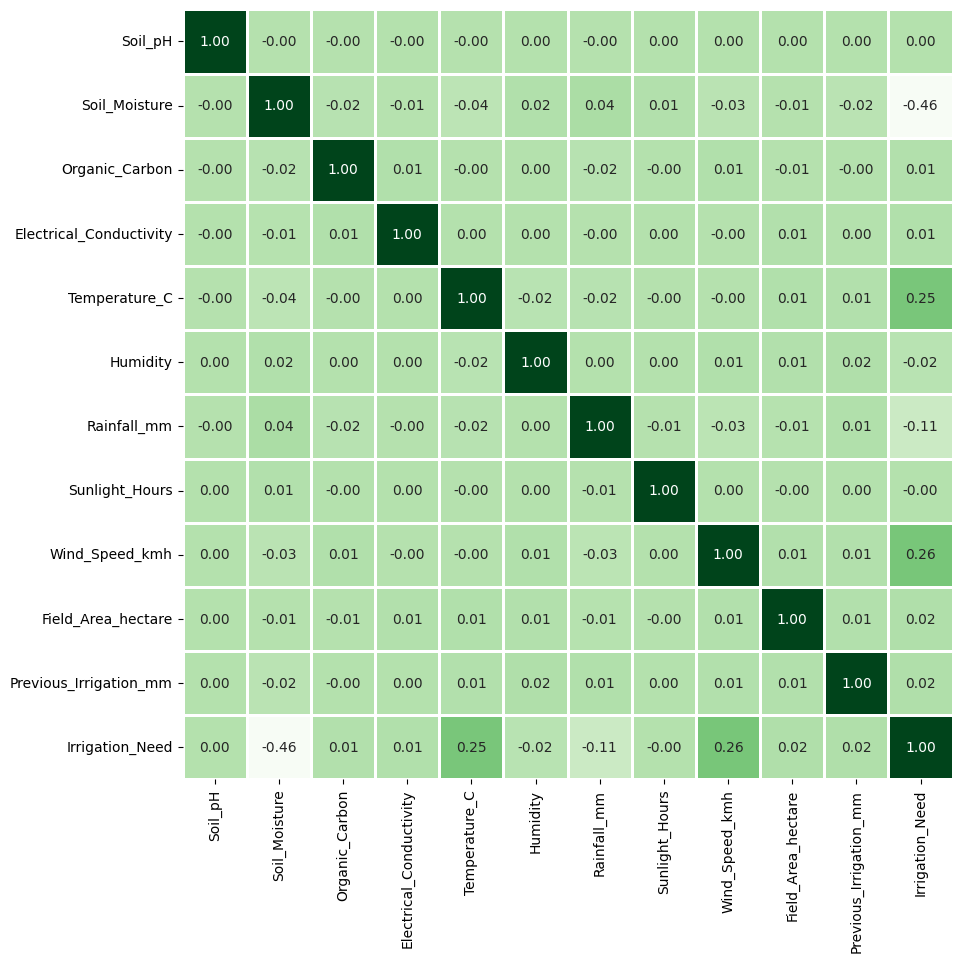

In [10]:
#Corelation matrix
#get numeric features
numeric_features= data_train_X.drop(data_train_X.select_dtypes(exclude=['number']).columns, axis=1)
plt.figure(figsize=(10, 10))
corr = pd.concat([numeric_features, data_train_y], axis=1).corr()
sns.heatmap(corr, fmt = '0.2f', cmap = 'Greens', square=True, annot=True, linewidths=1, cbar=False)
plt.show()

In [11]:
#sns.pairplot(numeric_features)
#plt.show()

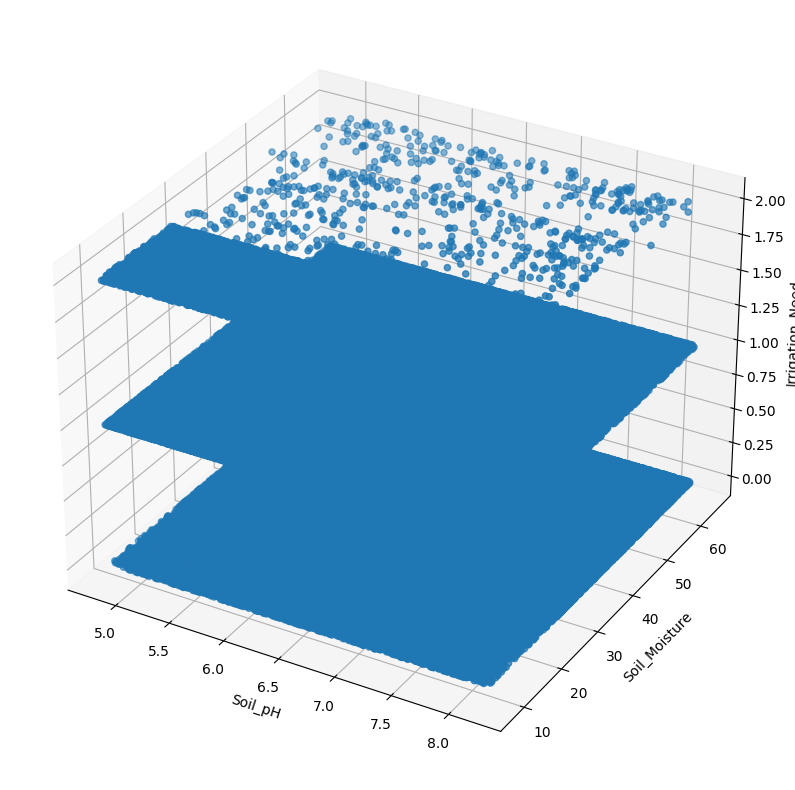

In [12]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_train_X['Soil_pH'], data_train_X['Soil_Moisture'], data_train_y)
ax.set_xlabel('Soil_pH')
ax.set_ylabel('Soil_Moisture')
ax.set_zlabel('Irrigation_Need')
plt.show()
#sns.boxplot(x= data_train_X['Soil_Type'], y=data_train_X['Soil_pH'])
#plt.show()

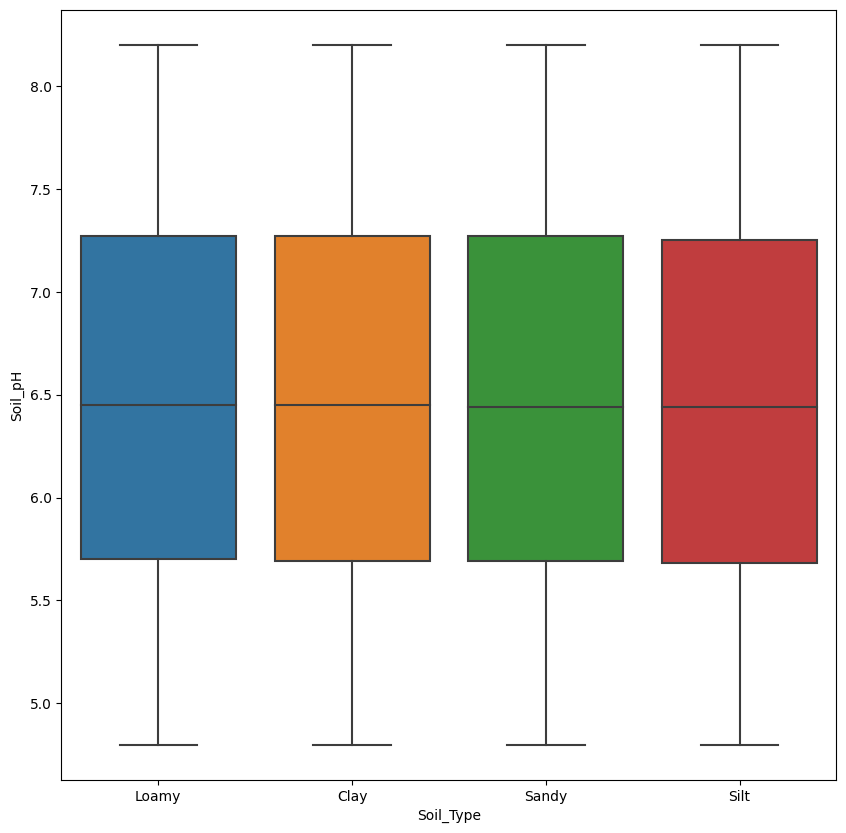

In [13]:

fig = plt.figure(figsize=(10, 10))
sns.boxplot(x= data_train_X['Soil_Type'], y=data_train_X['Soil_pH'])
plt.show()

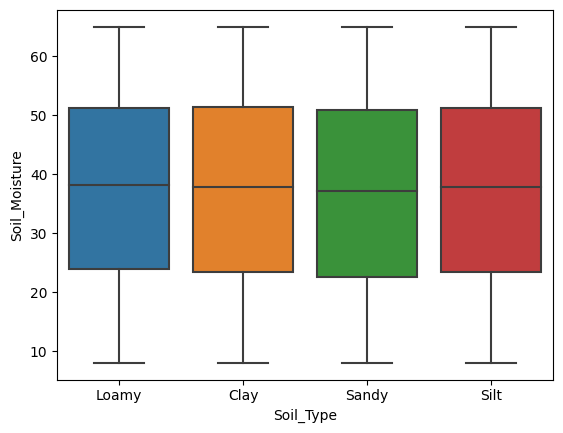

In [14]:
sns.boxplot(x= data_train_X['Soil_Type'], y=data_train_X['Soil_Moisture'])
plt.show()


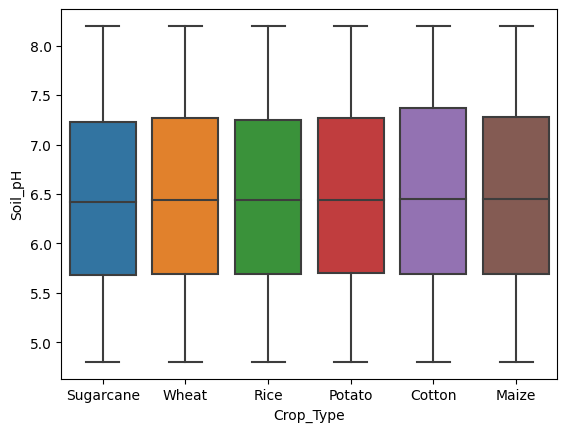

In [15]:
sns.boxplot(x=data_train_X['Crop_Type'], y=data_train_X['Soil_pH'])
plt.show()

In [16]:
"""
x= data_train.groupby("Crop_Growth_Stage")["Irrigation_Need"].median().plot(kind="bar")
plt.title("Average Irrigation Need by Crop Growth Stage")
plt.xlabel("Crop Growth Stage")
plt.ylabel("Average Irrigation Need")
plt.show()


"""

#bar plot crop_growth stage vs irrigation need
x= data_train.groupby("Crop_Growth_Stage")["Irrigation_Need"].median().plot(kind="bar")
plt.title("Average Irrigation Need by Crop Growth Stage")
plt.xlabel("Crop Growth Stage")
plt.ylabel("Average Irrigation Need")
plt.show()

TypeError: could not convert string to float: 'Medium'